# Mutual Fund Risk Classification & Portfolio Recommendation

classification with XGbost and K mean clustering with PCA



In [18]:
# Core libraries: pandas/numpy for data handling, matplotlib/seaborn for plots,
# sklearn for preprocessing/modeling/clustering, xgboost for the classifier.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import xgboost as xgb
sns.set_style("whitegrid")

## 1. Load Dataset

In [19]:
# Read the raw  This is 814 mutual funds x 20 columns
df = pd.read_csv("comprehensive_mutual_funds_data.csv")
print(df.shape)
df.head(8)

(814, 20)


,scheme_name,min_sip,min_lumpsum,expense_ratio,fund_size_cr,fund_age_yr,fund_manager,sortino,alpha,sd,beta,sharpe,risk_level,amc_name,rating,category,sub_category,returns_1yr,returns_3yr,returns_5yr
0,Aditya Birla SL Active Debt Multi-Mgr FoF-Dir ...,100,100,0.27,10.0,10,Kaustubh Gupta,0.32,2.24,9.39,0.01,0.24,3,Aditya Birla Sun Life Mutual Fund,3,Other,FoFs Domestic,4.0,6.5,6.9
1,Aditya Birla SL Arbitrage Fund,1000,1000,0.36,4288.0,10,Lovelish Solanki,1.33,1.53,0.72,0.56,1.1,1,Aditya Birla Sun Life Mutual Fund,3,Hybrid,Arbitrage Mutual Funds,5.6,4.8,5.5
2,Aditya Birla SL Asset Allocator FoF-Dir Growth,1000,1000,0.53,157.0,10,Vinod Narayan Bhat,3.44,2.67,10.58,0.67,1.42,5,Aditya Birla Sun Life Mutual Fund,3,Other,FoFs Domestic,2.0,18.9,9.7
3,Aditya Birla SL Bal Bhavishya Yojna – Dir Growth,500,1000,0.76,637.0,4,Atul Penkar,2.18,-6.37,14.99,0.85,0.9,6,Aditya Birla Sun Life Mutual Fund,2,Solution Oriented,Childrens Funds,-0.7,17.1,NaN
4,Aditya Birla SL Balanced Advantage Fund,100,100,0.61,6386.0,10,Mohit Sharma,3.69,1.99,10.38,0.68,1.39,6,Aditya Birla Sun Life Mutual Fund,4,Hybrid,Dynamic Asset Allocation or Balanced Advantage,4.5,18.6,9.7
5,Aditya Birla SL Banking&Financial Services-Dir...,1000,1000,1.17,2384.0,9,Dhaval Gala,2.07,1.24,25.53,0.96,0.97,6,Aditya Birla Sun Life Mutual Fund,2,Equity,Sectoral / Thematic Mutual Funds,5.3,24.6,9.2
6,Aditya Birla SL Banking&PSU Debt Fund,1000,1000,0.37,7994.0,10,Kaustubh Gupta,1.92,4.46,1.91,1.78,1.09,3,Aditya Birla Sun Life Mutual Fund,4,Debt,Banking and PSU Mutual Funds,4.5,6.8,7.3
7,Aditya Birla SL CEF – Global Agri Plan-Direct ...,1000,1000,1.29,15.0,10,Vinod Narayan Bhat,1.42,-,20.18,-,1.06,6,Aditya Birla Sun Life Mutual Fund,0,Equity,Sectoral / Thematic Mutual Funds,-10.3,29.4,9.3


## 2. Data Cleaning

`sortino`, `alpha`, `sd`, `beta`, and `sharpe` are stored as text because some funds use `"-"` for "not available" — converting them forces those into proper missing values (`NaN`).

For imputation, we fill missing values using the **median within each `sub_category`** rather than one global median — funds in the same sub-category (e.g. Liquid Funds, Small Cap Funds) tend to have similar risk/return profiles, so this is a more realistic fill than borrowing a number from a totally different type of fund.

In [20]:
# Some ratio columns are text because of "-" placeholders for missing data.
# pd.to_numeric with errors="coerce" turns those into real NaNs we can work with.
cols_to_convert = ["sortino", "alpha", "sd", "beta", "sharpe"]
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill missing values fund-by-fund-type (sub_category), not with one global number --
# a debt fund's typical volatility is nothing like a small-cap equity fund's.
impute_cols = ["sortino", "alpha", "sd", "beta", "sharpe", "returns_3yr", "returns_5yr"]
for col in impute_cols:
    df[col] = df.groupby("sub_category")[col].transform(lambda x: x.fillna(x.median()))

# Safety net: if an entire sub_category was missing a column, fall back to the global median.
df[impute_cols] = df[impute_cols].fillna(df[impute_cols].median())

print(df[impute_cols].isna().sum())

sortino        0
alpha          0
sd             0
beta           0
sharpe         0
returns_3yr    0
returns_5yr    0
dtype: int64


## 3. Risk Category (Target Variable)


In [21]:
# risk_level is a 1-6 scale; bucket it into three human-readable classes.
# This is the column we're ultimately trying to predict.
def map_risk(x):
    if x <= 2:
        return "Low"
    elif x <= 4:
        return "Medium"
    else:
        return "High"

df["risk_category"] = df["risk_level"].apply(map_risk)
df["risk_category"].value_counts()

,count
risk_category,
High,445
Medium,189
Low,180


## 4. Exploratory Data Analysis


### 4.1 Do higher-risk funds actually deliver higher returns?

/tmp/ipykernel_1384/2470439499.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="risk_category", y="returns_3yr", order = ["Low", "Medium", "High"], palette="viridis")


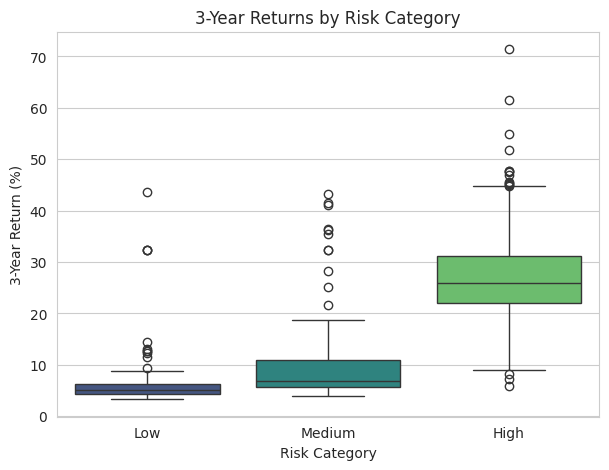

risk_category
High      26.86
Low        6.06
Medium     9.53
Name: returns_3yr, dtype: float64


In [22]:
# Boxplot of 3-year returns split by risk category -- checks whether "High risk" funds
# are actually earning investors more, or just swinging around with no real payoff.
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="risk_category", y="returns_3yr", order = ["Low", "Medium", "High"], palette="viridis")
plt.title("3-Year Returns by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("3-Year Return (%)")
plt.show()

print(df.groupby("risk_category")["returns_3yr"].mean().round(2))

**Takeaway:** yes, clearly. High-risk funds average around 27% 3-year returns versus roughly 6% for Low-risk and 9-10% for Medium-risk — and the box for "High" is much wider, meaning more variability too. In plain terms: the extra risk in this data does come with a real return premium on average, but also a lot more spread between the best and worst performers.

### 4.2 What's actually driving the risk label?

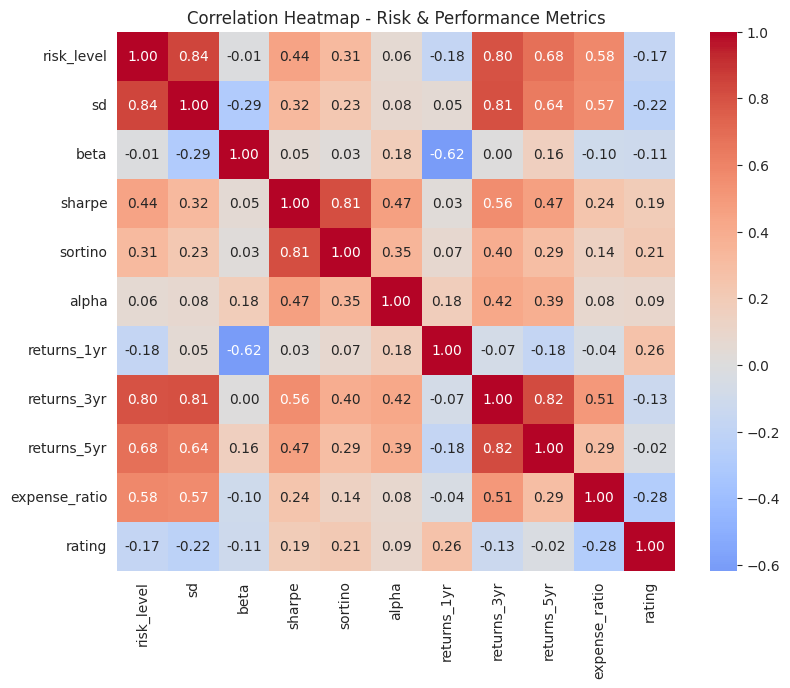

In [23]:
# Correlation heatmap -- shows which numeric columns move together with risk_level,
# and with each other. This is what motivated splitting features into "full" vs
# "fundamental-only" later on -- some columns are suspiciously close to the label itself.
corr_cols = ["risk_level", "sd", "beta", "sharpe", "sortino", "alpha",
             "returns_1yr", "returns_3yr", "returns_5yr", "expense_ratio", "rating"]
plt.figure(figsize=(9,7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Risk & Performance Metrics")
plt.show()

**Takeaway:** `sd` (standard deviation of returns) correlates with `risk_level` at **0.84** — by far the strongest relationship in the table, well ahead of `returns_3yr` (0.80) or `expense_ratio` (0.58). `beta` and `rating`, on the other hand, barely correlate with risk at all (close to 0). This is direct evidence for the leakage check we run later in the notebook: `sd` in particular is close enough to being "risk_level in disguise" that a model leaning on it isn't learning much a human wouldn't already know.

### 4.3 Where does the cost difference come from?

/tmp/ipykernel_1384/2022567761.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_expense.values, y=cat_expense.index, palette="magma")


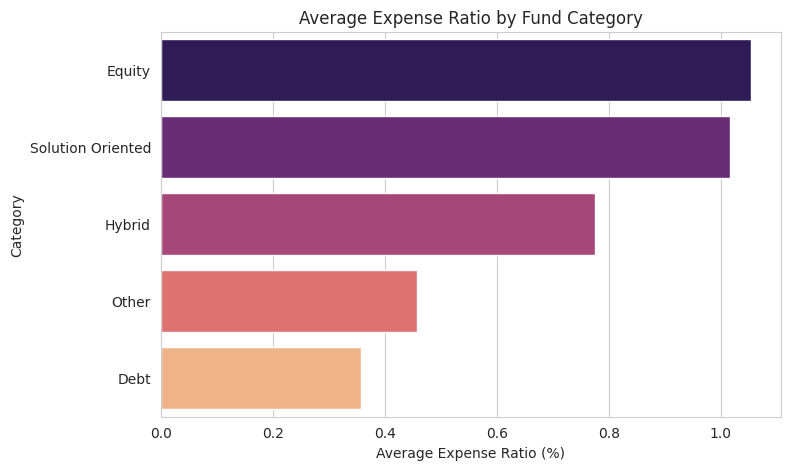

category
Equity               1.054
Solution Oriented    1.017
Hybrid               0.775
Other                0.457
Debt                 0.358
Name: expense_ratio, dtype: float64


In [24]:
# Average expense ratio per fund category -- tests the common assumption that
# actively-managed equity funds cost more to run than passive/debt funds.
plt.figure(figsize=(8,5))
cat_expense = df.groupby("category")["expense_ratio"].mean().sort_values(ascending=False)
sns.barplot(x=cat_expense.values, y=cat_expense.index, palette="magma")
plt.title("Average Expense Ratio by Fund Category")
plt.xlabel("Average Expense Ratio (%)")
plt.ylabel("Category")
plt.show()

print(cat_expense.round(3))

### 4.4 What kinds of funds make up this dataset?

/tmp/ipykernel_1384/198429759.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette="flare")


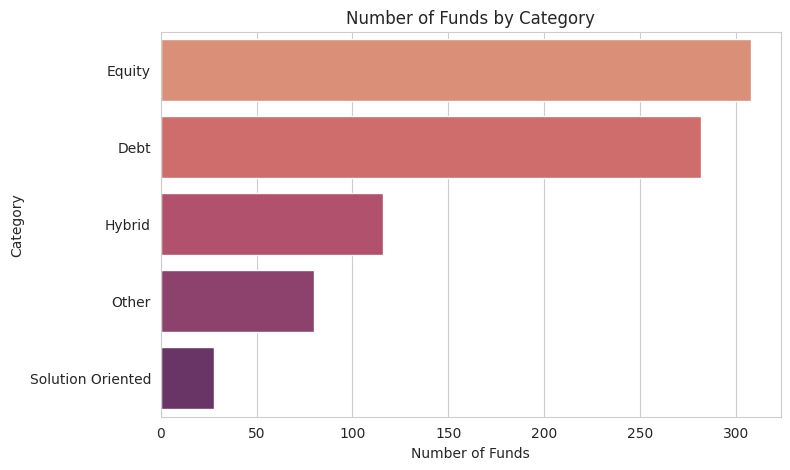

In [25]:
# Category counts -- basic composition check so we know what we're actually
# training on (e.g. is this mostly equity funds, or a genuine mix?).
plt.figure(figsize=(8,5))
cat_counts = df["category"].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette="flare")
plt.title("Number of Funds by Category")
plt.xlabel("Number of Funds")
plt.ylabel("Category")
plt.show()

## 5. Feature Engineering

New columns beyond the original project:

- `category_enc`, `sub_category_enc`, `amc_name_enc` — label-encoded versions of fund type and fund house, previously unused.
- `fund_manager_fund_count` — how many funds a manager currently runs, as a rough proxy for experience/workload (using the raw manager name directly would be too high-cardinality — 260 unique managers — for a model this size).
- `expense_efficiency` — 3-year return earned per unit of expense ratio paid, a simple cost-effectiveness signal.

In [26]:
# Turn the text categorical columns into numbers a model can use.
# LabelEncoder is fine here since XGBoost splits on values rather than assuming
# a linear relationship between the encoded numbers.
cat_cols = ["category", "sub_category", "amc_name"]
encoders = {}
for col in cat_cols:
    le_cat = LabelEncoder()
    df[col + "_enc"] = le_cat.fit_transform(df[col])
    encoders[col] = le_cat

# Proxy for manager experience/workload: how many funds does this person currently run?
# (Using the raw manager name would create 260 near-useless one-off categories.)
df["fund_manager_fund_count"] = df.groupby("fund_manager")["fund_manager"].transform("count")

# Cost-effectiveness signal: how much 3yr return per unit of expense ratio paid.
df["expense_efficiency"] = df["returns_3yr"] / df["expense_ratio"].replace(0, np.nan)
df["expense_efficiency"] = df["expense_efficiency"].fillna(df["expense_efficiency"].median())

## 6. Feature Scaling


In [27]:
# Preview only -- shows what StandardScaler does to the raw numbers.
# (The actual scaling used for training happens inside train_and_evaluate() below,
# fit fresh on each train split, so no information from the test set leaks in.)
preview_features = [
    "expense_ratio", "fund_size_cr", "fund_age_yr",
    "returns_1yr", "returns_3yr", "returns_5yr", "rating",
    "sortino", "alpha", "sd", "beta", "sharpe"
]

print("Before scaling:")
print(df[preview_features].agg(["mean", "std"]).T.round(2))

scaler_preview = StandardScaler()
scaled_preview = pd.DataFrame(scaler_preview.fit_transform(df[preview_features]), columns=preview_features)

print("\nAfter scaling:")
print(scaled_preview.agg(["mean", "std"]).T.round(2))

Before scaling:
                  mean      std
expense_ratio     0.71     0.48
fund_size_cr   3812.85  7181.48
fund_age_yr       8.32     2.64
returns_1yr       3.92     6.68
returns_3yr      18.24    12.10
returns_5yr       9.36     3.59
rating            2.64     1.46
sortino           2.65     1.38
alpha             2.52     3.86
sd               10.07     7.82
beta              0.84     1.29
sharpe            1.20     0.53

After scaling:
               mean  std
expense_ratio   0.0  1.0
fund_size_cr   -0.0  1.0
fund_age_yr    -0.0  1.0
returns_1yr     0.0  1.0
returns_3yr    -0.0  1.0
returns_5yr     0.0  1.0
rating          0.0  1.0
sortino        -0.0  1.0
alpha           0.0  1.0
sd             -0.0  1.0
beta            0.0  1.0
sharpe          0.0  1.0


## 7. Two Feature Sets — Testing the Volatility-Feature Question

- `features_full` — everything, including the volatility/risk-return measures (`sortino`, `alpha`, `sd`, `beta`, `sharpe`).
- `features_fundamental` — everything *except* those, so the model has to rely on fund characteristics (cost, size, age, category, house, accessibility) and raw returns instead.

If `features_full` scores much higher, that gap is mostly the volatility columns "giving away" the answer (see the 0.84 correlation from the EDA heatmap above). If the two are close, it means the fundamental characteristics genuinely carry the signal — a more defensible model for a portfolio project.

In [28]:
# volatility_features are the columns flagged as risky-to-use during EDA (high correlation with risk_level).
volatility_features = ["sortino", "alpha", "sd", "beta", "sharpe"]

# base_features = everything else -- fund characteristics + returns + our engineered columns.
base_features = [
    "expense_ratio", "fund_size_cr", "fund_age_yr",
    "returns_1yr", "returns_3yr", "returns_5yr", "rating",
    "category_enc", "sub_category_enc", "amc_name_enc",
    "min_sip", "min_lumpsum", "fund_manager_fund_count", "expense_efficiency"
]

features_full = base_features + volatility_features
features_fundamental = base_features

print(f"Full feature set: {len(features_full)} features")
print(f"Fundamental-only feature set: {len(features_fundamental)} features")

Full feature set: 19 features
Fundamental-only feature set: 14 features


## 8. Encode the Target & Train/Evaluate Both Models

In [29]:
# Encode the text labels (Low/Medium/High) into 0/1/2 for the model, keeping
# le_target around so we can turn predictions back into readable labels later.
le_target = LabelEncoder()
df["risk_encoded"] = le_target.fit_transform(df["risk_category"])

In [30]:
def train_and_evaluate(feature_list, label):
    # 1. Pull out the chosen feature columns and the target.
    X = df[feature_list]
    y = df["risk_encoded"]

    # 2. Scale features -- fit *only* on this split's data so nothing about the
    #    test set leaks into training (this is the "real" scaling step; section 6
    #    above was just a preview of what it does to the numbers).
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 3. Stratified split keeps the Low/Medium/High proportions consistent between
    #    train and test, which matters given the class imbalance we saw in EDA.
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

    # 4. Train an XGBoost multi-class classifier.
    model = xgb.XGBClassifier(
        objective="multi:softmax",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    )
    model.fit(X_train, y_train)

    # 5. Evaluate and report per-class performance, not just overall accuracy.
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n=== {label} ({len(feature_list)} features) ===")
    print(f"Accuracy: {acc:.3f}")
    print(classification_report(y_test, y_pred, target_names=le_target.classes_))

    return model, acc, X_test, y_test, y_pred


model_full, acc_full, Xte_full, yte_full, ypred_full = train_and_evaluate(
    features_full, "Full model (incl. volatility features)"
)
model_fund, acc_fund, Xte_fund, yte_fund, ypred_fund = train_and_evaluate(
    features_fundamental, "Fundamental-only model (no volatility features)"
)

print(f"\nAccuracy gap (full - fundamental): {acc_full - acc_fund:+.3f}")


=== Full model (incl. volatility features) (19 features) ===
Accuracy: 0.890
              precision    recall  f1-score   support

        High       0.98      0.98      0.98        89
         Low       0.77      0.83      0.80        36
      Medium       0.80      0.74      0.77        38

    accuracy                           0.89       163
   macro avg       0.85      0.85      0.85       163
weighted avg       0.89      0.89      0.89       163


=== Fundamental-only model (no volatility features) (14 features) ===
Accuracy: 0.896
              precision    recall  f1-score   support

        High       0.98      0.99      0.98        89
         Low       0.78      0.86      0.82        36
      Medium       0.82      0.71      0.76        38

    accuracy                           0.90       163
   macro avg       0.86      0.85      0.85       163
weighted avg       0.90      0.90      0.89       163


Accuracy gap (full - fundamental): -0.006


## 9. Confusion Matrix & Feature Importance (Fundamental Model)

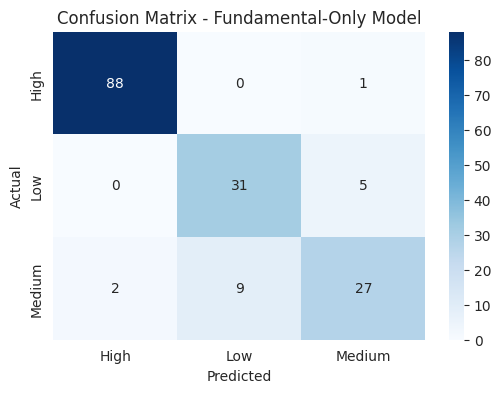

<Figure size 800x500 with 0 Axes>

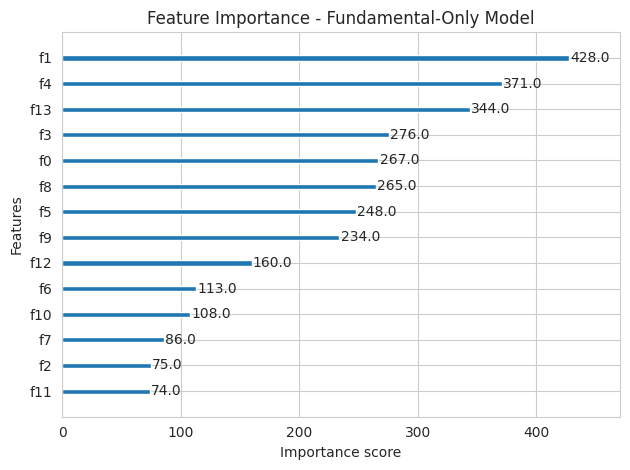

In [31]:
# Confusion matrix -- shows exactly which risk categories get confused with which,
# which is more informative than a single accuracy number given the class imbalance.
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(yte_fund, ypred_fund), annot=True, fmt="d",
            xticklabels=le_target.classes_, yticklabels=le_target.classes_, cmap="Blues")
plt.title("Confusion Matrix - Fundamental-Only Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature importance -- which columns the model actually leaned on most.
plt.figure(figsize=(8,5))
xgb.plot_importance(model_fund, importance_type="weight", max_num_features=15)
plt.title("Feature Importance - Fundamental-Only Model")
plt.tight_layout()
plt.show()

## 10. Clustering with KMeans + PCA



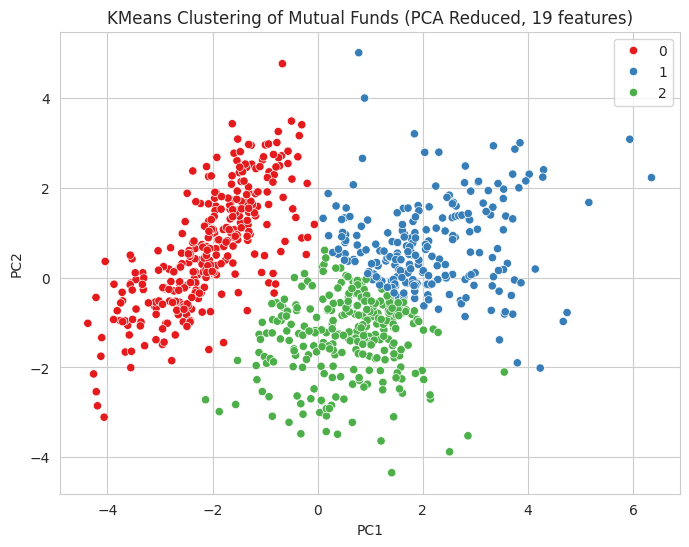

In [32]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
# Scale the full feature set for clustering (KMeans is distance-based, so scale matters here too).
scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(df[features_full])

# Reduce to 2 dimensions with PCA purely so we can plot the clusters -- the clustering
# itself works on the full scaled feature space, PCA is just for visualization.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_full)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)
df["cluster"] = clusters

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set1")
plt.title("KMeans Clustering of Mutual Funds (PCA Reduced, 19 features)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 11. Portfolio Recommendation Engine

In [33]:
def recommend_portfolio(risk_pref, top_n=5, category_pref=None, max_sip=None):
    """
    Recommend top mutual funds for an investor.

    risk_pref     : "Low" | "Medium" | "High"
    top_n         : number of funds to return
    category_pref : optional, e.g. "Equity", "Debt", "Hybrid"
    max_sip       : optional, investor's max monthly SIP budget (in Rs.)
    """
    # Start from funds matching the investor's risk appetite, then apply any optional filters.
    subset = df[df["risk_category"] == risk_pref].copy()

    if category_pref:
        subset = subset[subset["category"] == category_pref]
    if max_sip is not None:
        subset = subset[subset["min_sip"] <= max_sip]

    if subset.empty:
        print("No funds match these filters.")
        return pd.DataFrame()

    # Normalize each "higher is better" metric to 0-1 so returns (%) and rating (0-5)
    # don't distort the score just because they're on different scales.
    metrics_higher_better = ["returns_1yr", "returns_3yr", "returns_5yr", "sharpe", "rating"]
    for m in metrics_higher_better:
        rng = subset[m].max() - subset[m].min()
        subset[m + "_norm"] = (subset[m] - subset[m].min()) / rng if rng > 0 else 0.5

    # expense_ratio is "lower is better", so we invert it after normalizing.
    rng_exp = subset["expense_ratio"].max() - subset["expense_ratio"].min()
    subset["expense_ratio_norm"] = (
        1 - (subset["expense_ratio"] - subset["expense_ratio"].min()) / rng_exp
        if rng_exp > 0 else 0.5
    )

    # Weighted composite score -- longer-term returns and risk-adjusted quality (Sharpe)
    # matter more here than short-term (1yr) performance or star rating alone.
    weights = {
        "returns_3yr_norm": 0.30,
        "returns_5yr_norm": 0.20,
        "returns_1yr_norm": 0.10,
        "sharpe_norm": 0.20,
        "rating_norm": 0.10,
        "expense_ratio_norm": 0.10,
    }
    subset["score"] = sum(subset[col] * w for col, w in weights.items())

    top_funds = subset.sort_values("score", ascending=False).head(top_n)
    return top_funds[[
        "scheme_name", "amc_name", "category", "sub_category",
        "returns_1yr", "returns_3yr", "returns_5yr", "sharpe",
        "expense_ratio", "rating", "risk_category", "score"
    ]]

### Example usage

In [34]:
# A medium-risk investor who can invest a SIP of up to Rs. 1000/month
recommend_portfolio("Medium", top_n=5, max_sip=1000)

,scheme_name,amc_name,category,sub_category,returns_1yr,returns_3yr,returns_5yr,sharpe,expense_ratio,rating,risk_category,score
663,SBI Tax Advantage Fund,SBI Mutual Fund,Equity,ELSS Mutual Funds,1.9,41.1,21.80,1.85,1.76,0,Medium,0.661051
639,SBI Long Term Advantage Fund,SBI Mutual Fund,Equity,ELSS Mutual Funds,0.1,43.3,19.50,1.79,1.75,0,Medium,0.654169
679,Sundaram Emerging Small Cap Series IV – Dir Gr...,Sundaram Mutual Fund,Equity,Small Cap Mutual Funds,6.7,41.4,13.15,1.90,0.75,0,Medium,0.650194
487,Mahindra Manulife Equity Savings Fund,Mahindra Manulife Mutual Fund,Hybrid,Equity Savings Mutual Funds,1.7,32.4,13.30,1.56,0.70,4,Medium,0.633136
296,ICICI Pru Asset Allocator Fund,ICICI Prudential Mutual Fund,Other,FoFs Domestic,8.8,21.6,12.80,1.99,0.18,4,Medium,0.611681


In [35]:
# A high-risk investor specifically looking at Equity funds, no budget cap
recommend_portfolio("High", top_n=5, category_pref="Equity")

,scheme_name,amc_name,category,sub_category,returns_1yr,returns_3yr,returns_5yr,sharpe,expense_ratio,rating,risk_category,score
608,Quant Small Cap Fund,Quant Mutual Fund,Equity,Small Cap Mutual Funds,5.4,71.4,23.2,2.11,0.64,5,High,0.923922
603,Quant Infrastructure Fund,Quant Mutual Fund,Equity,Sectoral / Thematic Mutual Funds,5.6,61.5,21.1,2.30,0.64,5,High,0.866495
609,Quant Tax Plan- Direct Growth,Quant Mutual Fund,Equity,ELSS Mutual Funds,0.9,54.9,22.2,2.03,0.57,5,High,0.811582
606,Quant Mid Cap Fund,Quant Mutual Fund,Equity,Mid Cap Mutual Funds,8.8,45.1,19.8,1.95,0.63,5,High,0.742541
601,Quant Flexi Cap Fund,Quant Mutual Fund,Equity,Flexi Cap Funds,6.8,47.7,18.2,1.94,0.58,5,High,0.736107
